In [551]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import barycentric_interpolate

In [552]:
import pandas as pd
df = pd.read_csv('Kamaz_upper.csv', sep=';', header=None)
df = df.replace(',', '.', regex=True).astype(np.float32).values
x = df[:, 0]
y = df[:, 1]
der_b = -10

df = pd.read_csv('Kamaz_param.csv', sep=';', header=None)
df = df.replace(',', '.', regex=True).astype(np.float32).values
x_param = df[:, 0]
y_param = df[:, 1]

In [553]:
def get_coeffs(x, y):
    h = x[1:] - x[:-1]
    d = (y[1:] - y[:-1]) / h
    b = 6 * (d[1:] - d[:-1])

    A_up = np.diag(h[1:-1], k=1)
    A_middle = np.diag(2 * (h[1:] + h[:-1]), k=0)
    A_down = np.diag(h[1:-1], k=-1)

    A = A_up + A_middle + A_down

    A[-1][-1] += 0.5 * h[-1]
    b[-1] -= 3 * (der_b - d[-1])

    m = np.linalg.solve(A, b)

    m_0 = 0
    m_N = 3 / h[-1] * (der_b - d[-1]) - m[-1] / 2

    m = np.hstack([m_0, m, m_N])

    s0 = y[:-1]
    s1 = d - h / 6 * (2 * m[:-1] + m[1:])
    s2 = m[:-1] / 2
    s3 = (m[1:] - m[:-1]) / (6 * h)
    return s0, s1, s2, s3

In [554]:
def cubic_spline(x, y, bins):
    s0, s1, s2, s3 = get_coeffs(x, y)
    spline = np.array([])
    for k in range(len(s0)):
        local_bins = bins[(bins >= x[k]) & (bins <= x[k + 1])] - x[k]
        f = np.polyval([s3[k], s2[k], s1[k], s0[k]], local_bins)
        spline = np.append(spline, f)
    return spline

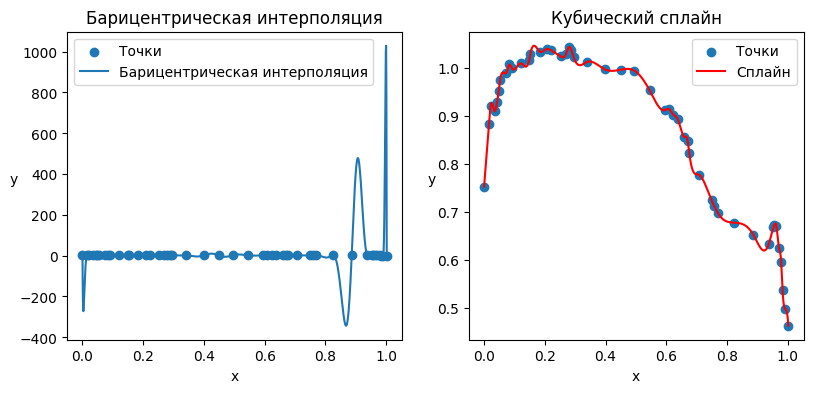

In [555]:
def plot_barycentric(ax):
    bins = np.linspace(x[0], x[-1], 1000)
    y_interp = barycentric_interpolate(x, y, bins)
    ax[0].scatter(x, y, label='Точки')
    ax[0].plot(bins, y_interp, label='Барицентрическая интерполяция')
    ax[0].legend()
    ax[0].set_xlabel('x')
    ax[0].set_ylabel('y', rotation=0)
    ax[0].set_title('Барицентрическая интерполяция')

def plot_cubic_spline(ax):
    ax[1].scatter(x, y, label='Точки')
    bins = np.linspace(x[0], x[-1], 1000)
    plt.plot(bins, cubic_spline(x, y, bins), color='red', label='Сплайн')
    ax[1].legend()
    ax[1].set_xlabel('x')
    ax[1].set_ylabel('y', rotation=0)
    ax[1].set_title('Кубический сплайн')

fig, ax = plt.subplots(ncols=2, figsize=(9.5, 4))
plot_barycentric(ax)
plot_cubic_spline(ax)
plt.savefig('figure1.png', dpi=300)
plt.legend()


In [556]:

def plot_derivative(ax, x, s1, s2, s3):
    for k in range(len(s3)):
        bins = np.linspace(x[k], x[k + 1], 100) - x[k]
        y = np.polyval([3 * s3[k], 2 * s2[k], s1[k]], bins)
        ax[0].plot(x[k] + bins, y, color='red')

    ax[0].set_xlabel('x')
    ax[0].set_ylabel('y', rotation=0)
    ax[0].set_title("S'(x)")
    ax[0].minorticks_on()
    ax[0].grid(True, which='major', linestyle='-')
    ax[0].grid(True, which='minor', linestyle='--', alpha=0.5)
    
def plot_derivative2(ax, x, s2, s3):
    for k in range(len(s3)):
        bins = np.linspace(x[k], x[k + 1], 100) - x[k]
        y = np.polyval([6 * s3[k], 2 * s2[k]], bins)
        ax[1].plot(x[k] + bins, y, color='green')

    ax[1].set_xlabel('x')
    ax[1].set_ylabel('y', rotation=0)
    ax[1].set_title("S''(x)")
    ax[1].minorticks_on()
    ax[1].grid(True, which='major', linestyle='-')
    ax[1].grid(True, which='minor', linestyle='--', alpha=0.5)
    

def plot_der12():
    fig, ax = plt.subplots(ncols=2, figsize=(9.5, 4))
    s0, s1, s2, s3 = get_coeffs(x, y)
    plot_derivative(ax, x, s1, s2, s3)
    plot_derivative2(ax, x, s2, s3)
    

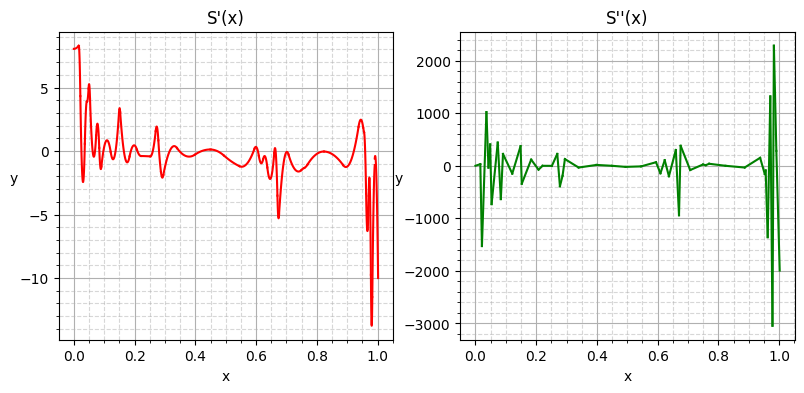

In [557]:
plot_der12()
plt.savefig('figure2.png', dpi=300)


In [558]:
def get_coeffs_param(x, y):
    h = x[1:] - x[:-1]
    d = (y[1:] - y[:-1]) / h
    b = 6 * (d[1:] - d[:-1])

    A_up = np.diag(h[1:-1], k=1)
    A_middle = np.diag(2 * (h[1:] + h[:-1]), k=0)
    A_down = np.diag(h[1:-1], k=-1)

    A = A_up + A_middle + A_down

    m = np.linalg.solve(A, b)

    m_0 = 0
    m_N = 0

    m = np.hstack([m_0, m, m_N])

    s0 = y[:-1]
    s1 = d - h / 6 * (2 * m[:-1] + m[1:])
    s2 = m[:-1] / 2
    s3 = (m[1:] - m[:-1]) / (6 * h)
    return s0, s1, s2, s3

def cubic_spline_param(x, y, bins):
    s0, s1, s2, s3 = get_coeffs_param(x, y)
    spline = np.array([])
    for k in range(len(s0)):
        local_bins = bins[(bins >= x[k]) & (bins <= x[k + 1])] - x[k]
        f = np.polyval([s3[k], s2[k], s1[k], s0[k]], local_bins)
        spline = np.append(spline, f)
    return spline

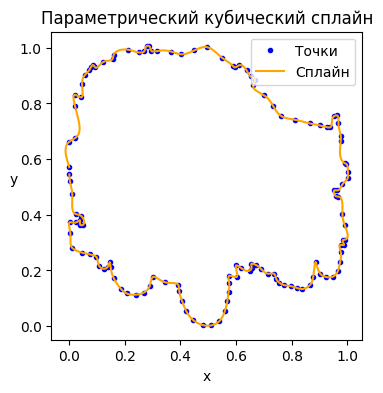

In [559]:
def cubic_spline_parametric(ax, x, y):
    t = np.zeros_like(x)
    t[1:] = np.cumsum(np.sqrt((x[1:] - x[:-1]) ** 2 + (y[1:] - y[:-1]) ** 2))
    bins = np.linspace(t[0], t[-1], 1000)
    
    ax.plot(x, y, 'o', label='Точки', markersize=3, color='blue')
    
    ax.plot(cubic_spline_param(t, x, bins), cubic_spline_param(t, y, bins), label='Сплайн', color='orange')
    ax.set_xlabel('x')
    ax.set_ylabel('y', rotation=0)
    ax.set_title("Параметрический кубический сплайн")
    ax.set_aspect('equal')
    ax.legend(loc=1)
fig, ax = plt.subplots(figsize=(6.5, 4))
cubic_spline_parametric(ax, x_param, y_param)
plt.savefig('figure3.png', dpi=300)

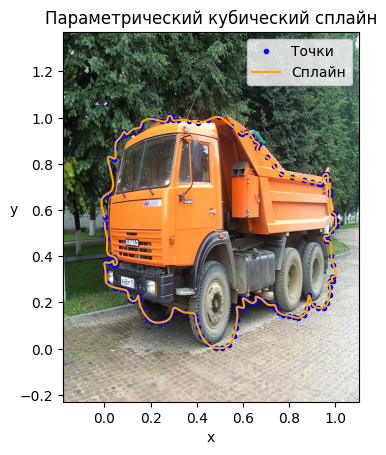

In [560]:
img = plt.imread('Kamaz_55111.JPG')
fig, ax = plt.subplots()
cubic_spline_parametric(ax, x_param, y_param)
extent = [-0.18, 1.1, -0.23, 1.37]
ax.imshow(img, alpha=1, zorder=0, extent=extent)

plt.savefig('figure4.png', dpi=300)